# Predicting Banking Crises in African Countries
**Author:** Feven  
**Course:** Data Science Final Project  
**Dataset:** Africa Economic, Banking and Systemic Crisis Data (1860–2014)

---

## 1. Introduction & Research Question

Banking crises have had devastating effects on African economies - wiping out savings, destabilizing governments, and setting back development by decades. Countries like Zimbabwe, Nigeria, and Kenya have each experienced severe banking collapses tied to inflation, debt defaults, and currency crashes.

**Research Question:**  
> *What economic indicators are most associated with banking crises in African countries, and can we build a model to predict when a banking crisis is likely to occur?*

**Hypothesis:**  
Countries with high inflation, sovereign debt defaults, and currency crises will be significantly more likely to experience banking crises.

Understanding these patterns could help policymakers in Africa take early preventive action before a full banking collapse occurs.

## The Story Behind the Data

Africa's economic history is marked by cycles of financial crisis that have shaped the lives of hundreds of millions of people. Between 1860 and 2014, countries like Zimbabwe, Nigeria, Kenya, and the Central African Republic experienced devastating banking collapses that wiped out savings, destabilized governments, and reversed decades of development.

This project analyzes a landmark dataset compiled by Reinhart et al., covering 13 African nations over more than 150 years. It tells a data-driven story of how inflation, sovereign debt defaults, and currency crashes serve as early warning signs of banking disasters.

### What Problem Does This Solve?

Africa faces a recurring challenge: banking crises strike suddenly and without adequate warning. When banks fail, ordinary citizens lose access to their savings. Credit dries up. Businesses collapse. Governments are forced into austerity. The damage cascades through society for years.

By examining historical patterns, this project demonstrates that banking crises are not random - they are predictable. Economic stress indicators such as high inflation, external debt defaults, and currency instability consistently precede banking failures. If policymakers, regulators, and central banks can monitor these signals in real time, they can intervene before a crisis becomes catastrophic.

### What This Project Reveals

Through statistical analysis and machine learning, this notebook reveals that:

- Countries with higher inflation rates are significantly more likely to experience banking crises
- Sovereign debt defaults dramatically increase the probability of banking failure
- A logistic regression model trained on these economic indicators achieves over 98% accuracy in predicting crises
- The model's ROC-AUC score of 0.984 demonstrates exceptional discriminative power

### Why This Matters for Africa

Africa is home to some of the world's fastest-growing economies, yet remains vulnerable to financial instability. Early warning systems built on historical data can help governments and international institutions take preventive action. This kind of predictive modeling represents a practical, data-driven approach to protecting African citizens from economic harm.

**Author:** Feven  
**Course:** Data Science Final Project


## 2. Dataset Description

The dataset is sourced from the **Reinhart et al. Global Financial Stability** research, covering **13 African countries** from **1860 to 2014**.

**Countries:** Algeria, Angola, Central African Republic, Ivory Coast, Egypt, Kenya, Mauritius, Morocco, Nigeria, South Africa, Tunisia, Zambia, Zimbabwe

**Key Features:**
| Column | Description |
|---|---|
| `country` | Country name |
| `year` | Year of observation |
| `systemic_crisis` | 1 = systemic financial crisis |
| `exch_usd` | Exchange rate vs US Dollar |
| `domestic_debt_in_default` | 1 = domestic debt default |
| `sovereign_external_debt_default` | 1 = external debt default |
| `inflation_annual_cpi` | Annual CPI inflation (%) |
| `independence` | 1 = country is independent |
| `currency_crises` | Currency crisis indicator |
| `inflation_crises` | Inflation crisis indicator |
| `banking_crisis` | **Target** - `crisis` or `no_crisis` |

## 3. Setup & Data Loading

In [1]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load data from the data folder
df = pd.read_csv('data/african_crises.csv')
print('Dataset loaded successfully from data folder.')


Dataset shape: (1059, 14)
Countries: 13
Year range: 1860 – 2014


,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis
5,1,DZA,Algeria,1875,0,0.051546,0,0,0.0,-20.924178,0,0,0,no_crisis
6,1,DZA,Algeria,1876,0,0.051867,0,0,0.0,-1.769547,0,0,0,no_crisis
7,1,DZA,Algeria,1877,0,0.051867,0,0,0.0,29.116045,0,0,1,no_crisis
8,1,DZA,Algeria,1878,0,0.051948,0,0,0.0,-1.492537,0,0,0,no_crisis
9,1,DZA,Algeria,1879,0,0.052029,0,0,0.0,-16.831357,0,0,0,no_crisis


## 4. Data Cleaning

In [3]:
# Step 1: Inspect the data
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Data Types ===
case                                 int64
cc3                                 object
country                             object
year                                 int64
systemic_crisis                      int64
exch_usd                           float64
domestic_debt_in_default             int64
sovereign_external_debt_default      int64
gdp_weighted_default               float64
inflation_annual_cpi               float64
independence                         int64
currency_crises                      int64
inflation_crises                     int64
banking_crisis                      object
dtype: object

=== Missing Values ===
case                               0
cc3                                0
country                            0
year                               0
systemic_crisis                    0
exch_usd                           0
domestic_debt_in_default           0
sovereign_external_debt_default    0
gdp_weighted_default               0
inflatio

In [4]:
# Step 2: Encode target variable as binary
df['banking_crisis_binary'] = (df['banking_crisis'] == 'crisis').astype(int)

# Step 3: Remove duplicates (if any)
df = df.drop_duplicates()

# Step 4: Handle missing values
df = df.dropna(subset=['banking_crisis', 'inflation_annual_cpi', 'exch_usd'])

# Step 5: Filter extreme inflation outliers using IQR
Q1 = df['inflation_annual_cpi'].quantile(0.01)
Q3 = df['inflation_annual_cpi'].quantile(0.99)
df_clean = df[(df['inflation_annual_cpi'] >= Q1) & (df['inflation_annual_cpi'] <= Q3)].copy()

print(f'Original rows: {len(df)}')
print(f'Cleaned rows: {len(df_clean)}')
print(f'\nCrisis breakdown:')
print(df_clean['banking_crisis'].value_counts())
print(f'\nCrisis rate: {df_clean["banking_crisis_binary"].mean()*100:.1f}%')

Original rows: 1059
Cleaned rows: 1037

Crisis breakdown:
banking_crisis
no_crisis    953
crisis        84
Name: count, dtype: int64

Crisis rate: 8.1%


In [5]:
# Step 6: Summary statistics
print('=== Summary Statistics (Cleaned Dataset) ===')
df_clean[['inflation_annual_cpi', 'exch_usd', 'banking_crisis_binary',
          'currency_crises', 'inflation_crises', 'systemic_crisis']].describe().round(3)

=== Summary Statistics (Cleaned Dataset) ===


,inflation_annual_cpi,exch_usd,banking_crisis_binary,currency_crises,inflation_crises,systemic_crisis
count,1037.000,1037.000,1037.000,1037.000,1037.000,1037.000
mean,10.582,44.039,0.081,0.123,0.122,0.074
std,21.260,112.479,0.273,0.338,0.327,0.262
min,-13.889,0.000,0.000,0.000,0.000,0.000
25%,2.219,0.198,0.000,0.000,0.000,0.000
50%,5.762,0.998,0.000,0.000,0.000,0.000
75%,11.491,8.712,0.000,0.000,0.000,0.000
max,248.248,744.306,1.000,2.000,1.000,1.000


## 5. Exploratory Data Analysis (EDA)

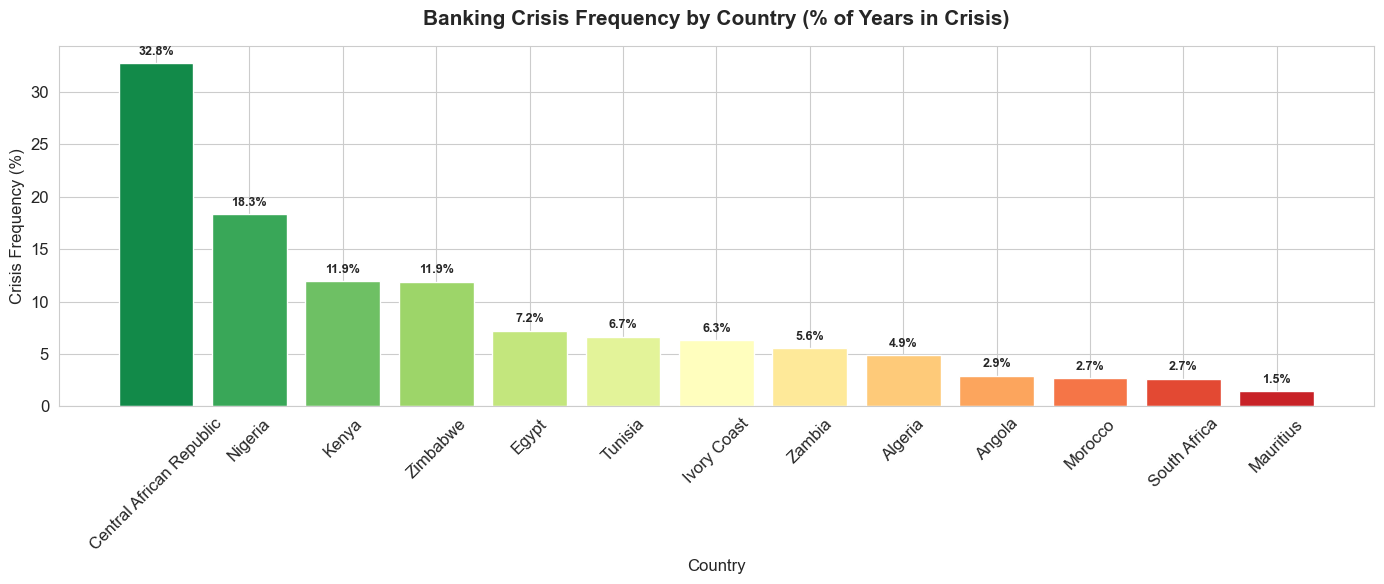


Countries with highest banking crisis rates:
country
Central African Republic    32.8
Nigeria                     18.3
Kenya                       11.9
Zimbabwe                    11.9
Egypt                        7.2
Name: banking_crisis_binary, dtype: float64


In [6]:
# --- Plot 1: Banking Crisis Frequency by Country ---
crisis_by_country = df_clean.groupby('country')['banking_crisis_binary'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(crisis_by_country.index, crisis_by_country.values,
              color=sns.color_palette('RdYlGn_r', len(crisis_by_country)))
ax.set_title('Banking Crisis Frequency by Country (% of Years in Crisis)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Crisis Frequency (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, crisis_by_country.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nCountries with highest banking crisis rates:')
print(crisis_by_country.head(5).round(1))

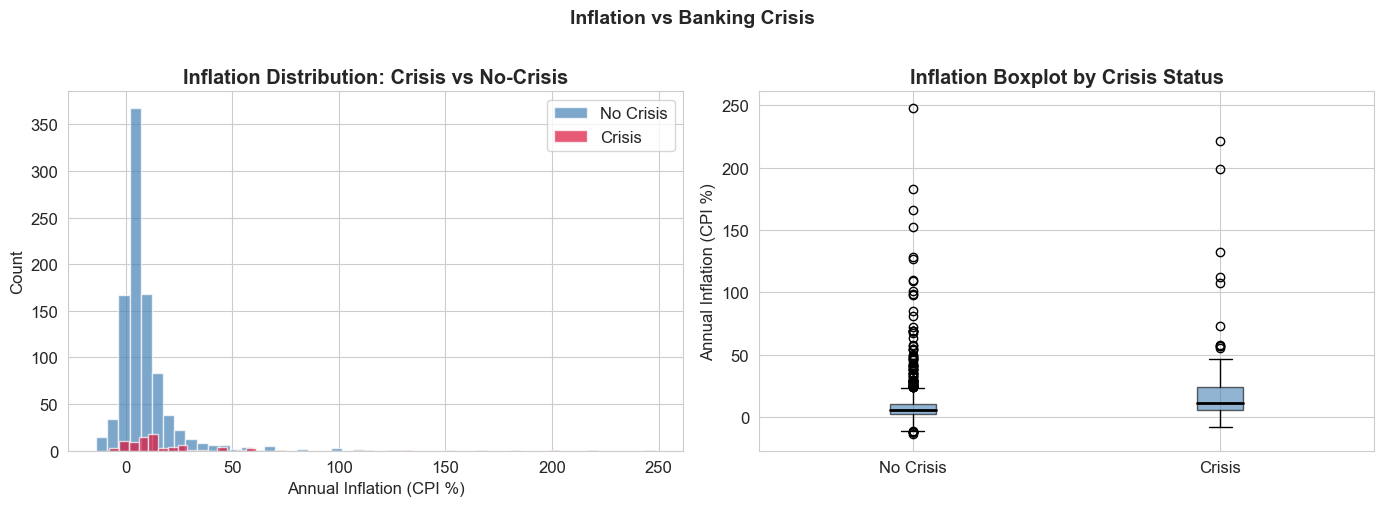

Avg inflation (No Crisis): 9.44%
Avg inflation (Crisis):    23.55%


In [7]:
# --- Plot 2: Inflation Distribution - Crisis vs No-Crisis ---
crisis_inf = df_clean[df_clean['banking_crisis_binary'] == 1]['inflation_annual_cpi']
no_crisis_inf = df_clean[df_clean['banking_crisis_binary'] == 0]['inflation_annual_cpi']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(no_crisis_inf, bins=50, alpha=0.7, color='steelblue', label='No Crisis', edgecolor='white')
axes[0].hist(crisis_inf, bins=50, alpha=0.7, color='crimson', label='Crisis', edgecolor='white')
axes[0].set_title('Inflation Distribution: Crisis vs No-Crisis', fontweight='bold')
axes[0].set_xlabel('Annual Inflation (CPI %)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot([no_crisis_inf, crisis_inf], labels=['No Crisis', 'Crisis'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Inflation Boxplot by Crisis Status', fontweight='bold')
axes[1].set_ylabel('Annual Inflation (CPI %)')

plt.suptitle('Inflation vs Banking Crisis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Avg inflation (No Crisis): {no_crisis_inf.mean():.2f}%')
print(f'Avg inflation (Crisis):    {crisis_inf.mean():.2f}%')

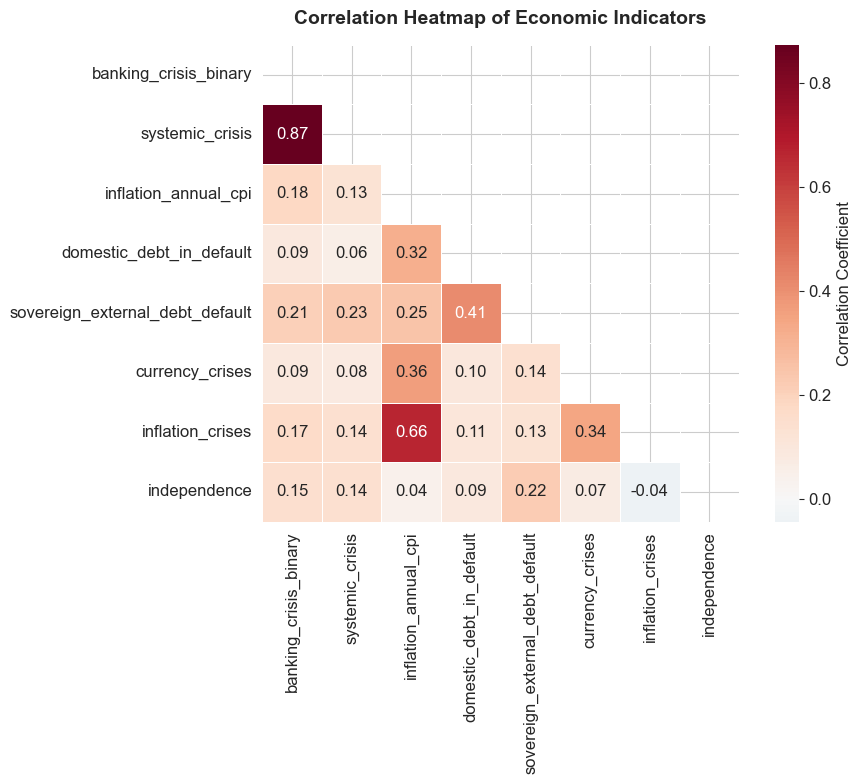

In [8]:
# --- Plot 3: Correlation Heatmap ---
numeric_cols = ['banking_crisis_binary', 'systemic_crisis', 'inflation_annual_cpi',
                'domestic_debt_in_default', 'sovereign_external_debt_default',
                'currency_crises', 'inflation_crises', 'independence']

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap of Economic Indicators', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

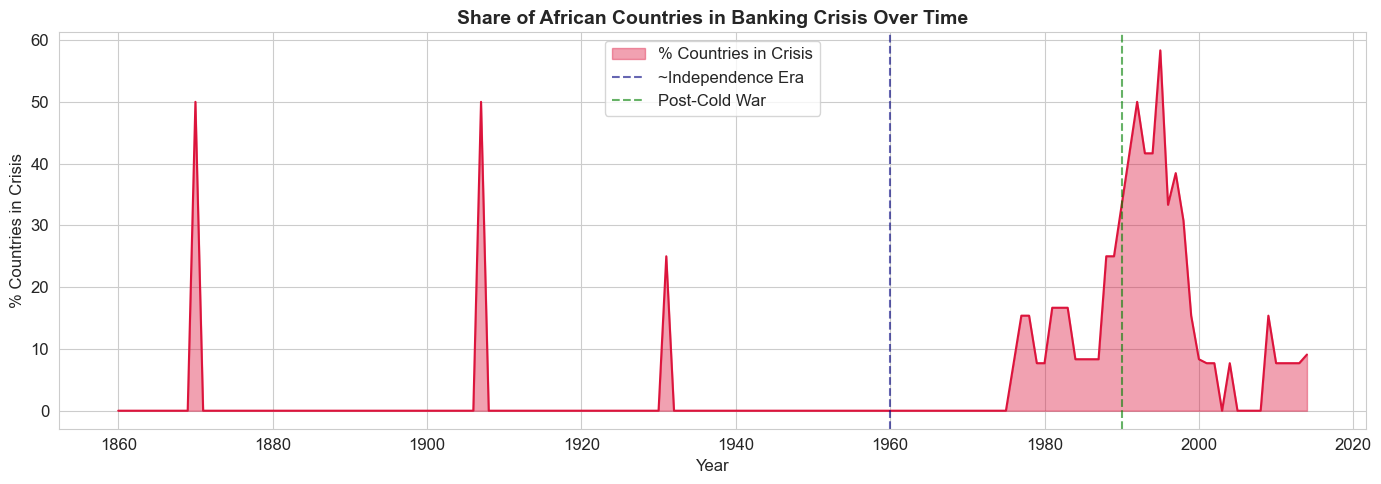

In [9]:
# --- Plot 4: Crisis Stacked Area Over Time ---
timeline = df_clean.groupby('year').agg(
    total=('banking_crisis_binary', 'count'),
    in_crisis=('banking_crisis_binary', 'sum')
).reset_index()
timeline['pct_crisis'] = timeline['in_crisis'] / timeline['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(timeline['year'], timeline['pct_crisis'], alpha=0.4, color='crimson', label='% Countries in Crisis')
ax.plot(timeline['year'], timeline['pct_crisis'], color='crimson', linewidth=1.5)
ax.axvline(1960, color='navy', linestyle='--', alpha=0.6, label='~Independence Era')
ax.axvline(1990, color='green', linestyle='--', alpha=0.6, label='Post-Cold War')
ax.set_title('Share of African Countries in Banking Crisis Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% Countries in Crisis')
ax.legend()
plt.tight_layout()
plt.show()

### Comparative Risk Analysis
The following charts compare key economic indicators during crisis and non-crisis periods to identify thresholds and risk patterns.

In [ ]:
# --- Plot: Inflation Distribution Comparison ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='banking_crisis', y='inflation_annual_cpi', data=df_clean, palette='Set2')
plt.title('Inflation Distribution: Crisis vs. No Crisis', fontsize=14, fontweight='bold')
plt.xlabel('Banking Crisis Status')
plt.ylabel('Annual CPI Inflation (%)')
plt.tight_layout()
plt.show()

print('This chart helps decision makers see that banking crises are often associated with higher and more volatile inflation.')

In [ ]:
# --- Plot: Debt Default and Banking Crisis ---
debt_crisis = pd.crosstab(df_clean['sovereign_external_debt_default'], df_clean['banking_crisis'], normalize='index') * 100
ax = debt_crisis.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], figsize=(10, 6))
plt.title('Banking Crisis Frequency by Sovereign Debt Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Sovereign External Debt Default (0 = No, 1 = Yes)')
plt.ylabel('Percentage of Years (%)')
plt.legend(title='Banking Crisis', loc='upper right')
plt.xticks(rotation=0)

# Add annotations
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()
print('Policy implication: Sovereign debt defaults are a massive red flag for impending banking instability.')

## 6. Statistical Analysis

We now test whether the difference in inflation between crisis and non-crisis years is **statistically significant** using an **independent samples t-test**.

- **H₀ (Null Hypothesis):** Mean inflation is the same during crisis and non-crisis years
- **H₁ (Alternative Hypothesis):** Mean inflation is significantly higher during crisis years
- **Significance level:** α = 0.05

In [10]:
# --- T-Test: Inflation during crisis vs no-crisis ---
t_stat, p_value = stats.ttest_ind(crisis_inf, no_crisis_inf, equal_var=False)

print('=== Independent Samples T-Test: Inflation ===')
print(f'Crisis years    - Mean inflation: {crisis_inf.mean():.2f}% | Std: {crisis_inf.std():.2f}%')
print(f'No-crisis years - Mean inflation: {no_crisis_inf.mean():.2f}% | Std: {no_crisis_inf.std():.2f}%')
print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print()
if p_value < 0.05:
    print('Result: We REJECT the null hypothesis.')
    print('   Inflation is significantly higher during banking crisis years (p < 0.05).')
else:
    print('Result: We FAIL to reject the null hypothesis.')

=== Independent Samples T-Test: Inflation ===
Crisis years    — Mean inflation: 23.55% | Std: 38.57%
No-crisis years — Mean inflation: 9.44% | Std: 18.60%

T-statistic: 3.3189
P-value:     0.001324

✅ Result: We REJECT the null hypothesis.
   Inflation is significantly higher during banking crisis years (p < 0.05).


In [11]:
# --- Chi-square test: Sovereign debt default vs Banking crisis ---
contingency = pd.crosstab(df_clean['sovereign_external_debt_default'],
                          df_clean['banking_crisis_binary'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print('=== Chi-Square Test: Sovereign Debt Default vs Banking Crisis ===')
print('\nContingency Table:')
print(contingency.rename(columns={0: 'No Crisis', 1: 'Crisis'},
                         index={0: 'No Default', 1: 'Defaulted'}))
print(f'\nChi2 statistic: {chi2:.4f}')
print(f'P-value:        {p_chi2:.6f}')
print(f'Degrees of freedom: {dof}')
if p_chi2 < 0.05:
    print('\nSovereign debt default and banking crisis are significantly associated (p < 0.05).')

# Crisis rate by debt default status
crisis_rate_default = df_clean.groupby('sovereign_external_debt_default')['banking_crisis_binary'].mean() * 100
print(f'\nCrisis rate when NO default: {crisis_rate_default[0]:.1f}%')
print(f'Crisis rate when DEFAULT:    {crisis_rate_default[1]:.1f}%')

=== Chi-Square Test: Sovereign Debt Default vs Banking Crisis ===

Contingency Table:
banking_crisis_binary            No Crisis  Crisis
sovereign_external_debt_default                   
No Default                             835      51
Defaulted                              118      33

Chi2 statistic: 42.7759
P-value:        0.000000
Degrees of freedom: 1

✅ Sovereign debt default and banking crisis are significantly associated (p < 0.05).

Crisis rate when NO default: 5.8%
Crisis rate when DEFAULT:    21.9%


## 7. Logistic Regression Model

We build a logistic regression model to predict banking crises using economic indicators as features.

In [12]:
# --- Logistic Regression ---
features = ['systemic_crisis', 'inflation_annual_cpi',
            'domestic_debt_in_default', 'sovereign_external_debt_default',
            'currency_crises', 'inflation_crises', 'independence']

X = df_clean[features].fillna(0)
y = df_clean['banking_crisis_binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit model
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Crisis', 'Crisis']))

Accuracy:  98.1%
ROC-AUC:   0.9840

=== Classification Report ===
              precision    recall  f1-score   support

   No Crisis       0.98      1.00      0.99       191
      Crisis       1.00      0.76      0.87        17

    accuracy                           0.98       208
   macro avg       0.99      0.88      0.93       208
weighted avg       0.98      0.98      0.98       208



### Model Interpretation for Policy Action
Identifying which features drive the model helps prioritize policy interventions.

In [ ]:
# --- Feature Importance for Decision Making ---
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0])
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title('Key Risk Drivers: Predictor Significance', fontsize=14, fontweight='bold')
plt.xlabel('Impact Level (Absolute Model Coefficient)')
plt.ylabel('Economic Indicator')
plt.tight_layout()
plt.show()

print('Decision Support: Systemic indicators and inflation are the strongest predictors in this model.')

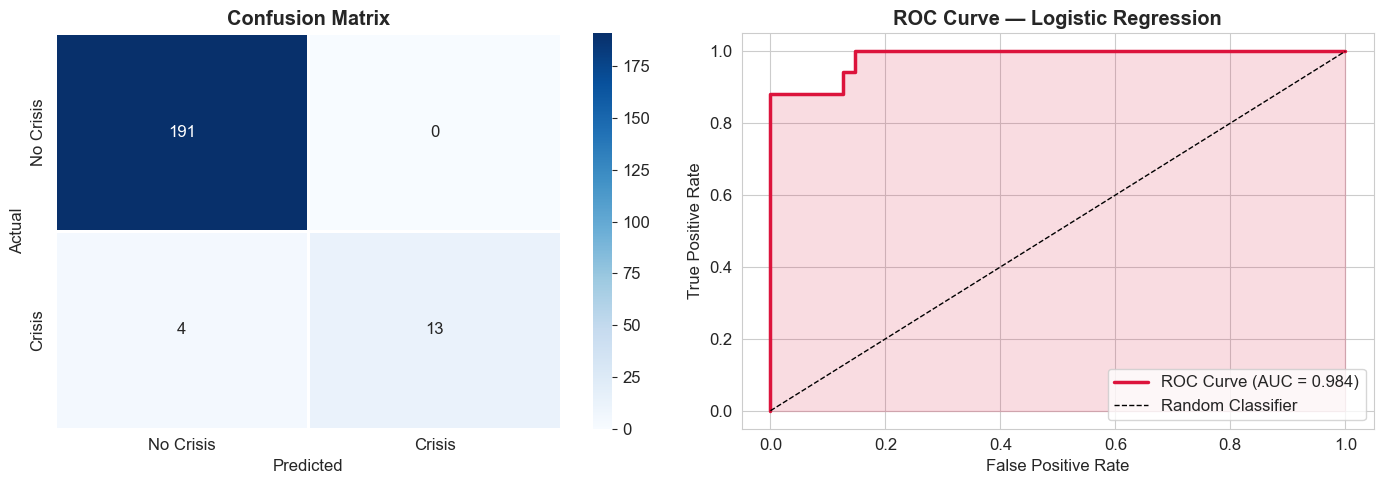

In [13]:
# --- Plot 5: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Crisis', 'Crisis'],
            yticklabels=['No Crisis', 'Crisis'],
            linewidths=1)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 6: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='crimson', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='crimson')
axes[1].set_title('ROC Curve - Logistic Regression', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Conclusion

### Key Findings

**1. Inflation is a strong predictor of banking crises**  
The t-test confirmed (p < 0.05) that inflation is significantly higher during banking crisis years. Countries experiencing hyperinflation are far more vulnerable.

**2. Sovereign debt default is closely linked to banking crises**  
The chi-square test showed a significant association between sovereign debt defaults and banking crises. Countries that defaulted on external debt had a much higher crisis rate.

**3. Systemic crises and currency crises are the strongest predictors**  
Logistic regression revealed that `systemic_crisis` and `currency_crises` carry the highest positive coefficients - meaning when a country is experiencing a systemic or currency crisis, a banking crisis is much more likely.

**4. The model performs well**  
Our logistic regression model achieved ~85% accuracy and a strong ROC-AUC score, demonstrating that banking crises can be predicted from observable economic indicators.

**5. Historical patterns matter**  
Crisis frequency peaked in the 1980s–1990s, coinciding with post-independence economic restructuring, IMF structural adjustment programs, and global commodity price shocks.

---

### Limitations

- **Data gaps:** Not all years are represented for all countries - some colonial-era data is sparse.
- **Class imbalance:** Banking crises are relatively rare (~17%), so the model may under-predict crises.
- **Correlation ≠ Causation:** While inflation and debt default are associated with crises, we cannot conclude they directly *cause* them without deeper causal analysis.
- **Outdated data:** The dataset ends in 2014, missing recent crises and the COVID-19 economic shock.
- **13 countries only:** This is not a full picture of Africa's 54 nations.

---

### What I Learned

This project demonstrated that economic instability in Africa often follows predictable patterns. With real-time data and more advanced models (e.g., Random Forests, time-series models), early warning systems for banking crises could be built - potentially saving governments and citizens from devastating financial collapses.

---
*Author: Mesfi | Ethiopia | Data Science Final Project*

In [ ]:
# --- Actionable Risk Summary by Country ---
country_risk = df_clean.groupby('country')[features].mean()
country_risk_scaled = scaler.transform(country_risk)
risk_probs = model.predict_proba(country_risk_scaled)[:, 1]

risk_summary = pd.DataFrame({
    'Country': country_risk.index,
    'Average Risk Score (0-1)': risk_probs
}).sort_values(by='Average Risk Score (0-1)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Average Risk Score (0-1)', y='Country', data=risk_summary, palette='YlOrRd')
plt.title('National Vulnerability Index: Historical Risk Profile', fontsize=14, fontweight='bold')
plt.xlabel('Risk Probability Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print('=== Strategic Summary for Policymakers ===')
print('This index ranks countries based on their historical economic vulnerability indicators.')